# Machine Learning Model

## Data Context

### Imports

In [3]:
import pandas as pd

%run "../utils/notebook_utils.py"
%run "../utils/feature_categories.py"

### Dataset Info

In [8]:
TRAINING_DATA = "../data/Training.parquet"
TARGET = "status"
full_data_frame = pd.read_parquet(TRAINING_DATA, engine='pyarrow')
full_data_frame[full_data_frame["https_token"] == 1]["url"]

0       https://www.todayshomeowner.com/how-to-make-ho...
3                                https://www.bedslide.com
4       https://tabs.ultimate-guitar.com/s/sex_pistols...
7       https://forums.digitalpoint.com/threads/how-to...
9       https://magalu-crediarioluiza.com/Produto_2020...
                              ...                        
7643    https://useful-maxim-276319.uc.r.appspot.com/o...
7647            https://www.cnet.com/internet-speed-test/
7653    https://snip.ly/www.netflix.com-signIn-account...
7656      https://www.computerhope.com/jargon/c/cdrom.htm
7657                             https://bravonia.com.tw/
Name: url, Length: 2965, dtype: str

### Dataset Statistics

In [3]:
full_data_frame.describe()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
count,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7658.0,7658.000000,...,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7.658000e+03,7658.000000,7658.000000,7658.000000
mean,61.031993,20.998694,0.148211,2.468399,1.003265,0.021154,0.142596,0.159441,0.0,0.293419,...,0.126665,0.778532,0.438104,0.074432,495.550535,4053.276443,8.679665e+05,0.021154,0.529381,3.192740
std,58.652024,10.207985,0.355332,1.378526,2.055865,0.152714,0.366461,0.834974,0.0,1.020342,...,0.332619,0.415262,0.496186,0.262490,860.938768,3104.632489,2.016619e+06,0.143908,0.499169,2.542354
min,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,-1.000000,-12.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,32.000000,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,84.000000,959.250000,0.000000e+00,0.000000,0.000000,1.000000
50%,47.000000,19.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,243.000000,3993.000000,2.161500e+03,0.000000,1.000000,3.000000
75%,70.000000,24.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,1.000000,0.000000,442.750000,7006.000000,3.822200e+05,0.000000,1.000000,5.000000
max,1641.000000,213.000000,1.000000,24.000000,32.000000,4.000000,3.000000,19.000000,0.0,19.000000,...,1.000000,1.000000,1.000000,1.000000,29829.000000,12874.000000,1.074572e+07,1.000000,1.000000,10.000000


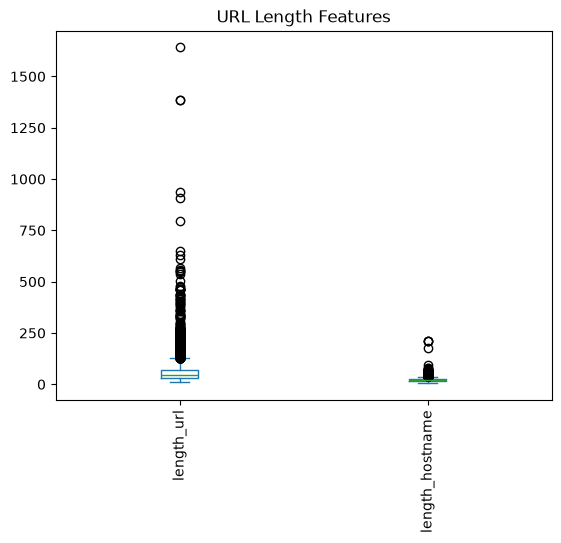

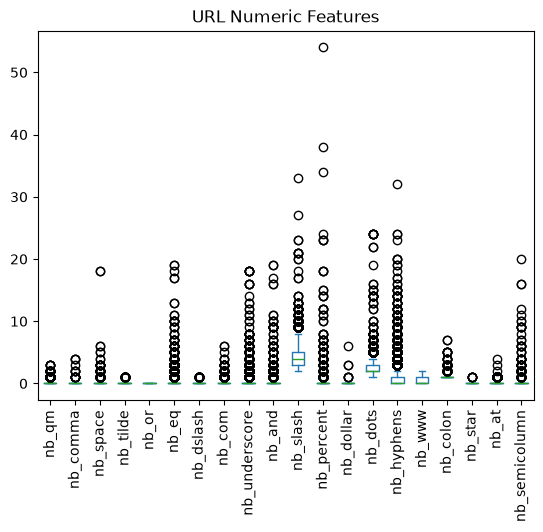

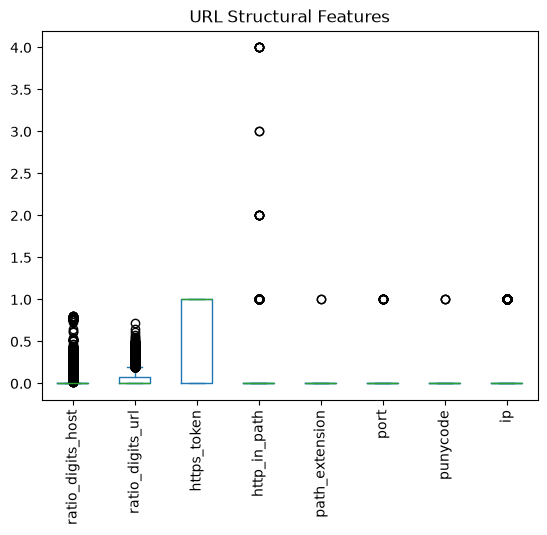

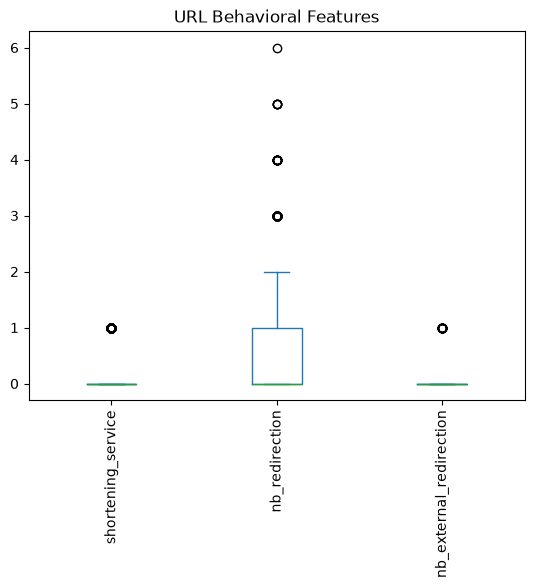

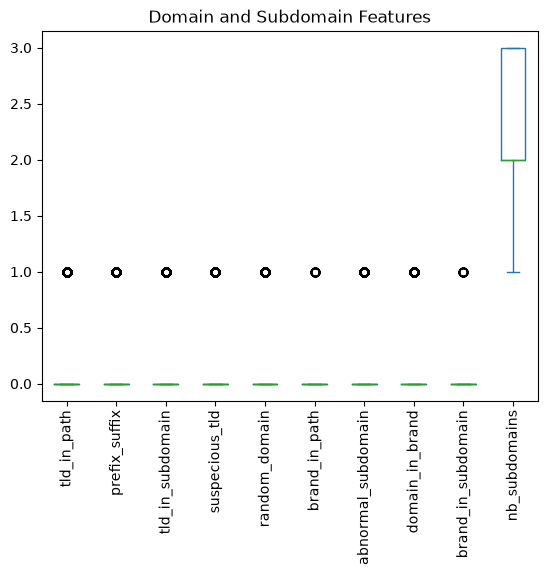

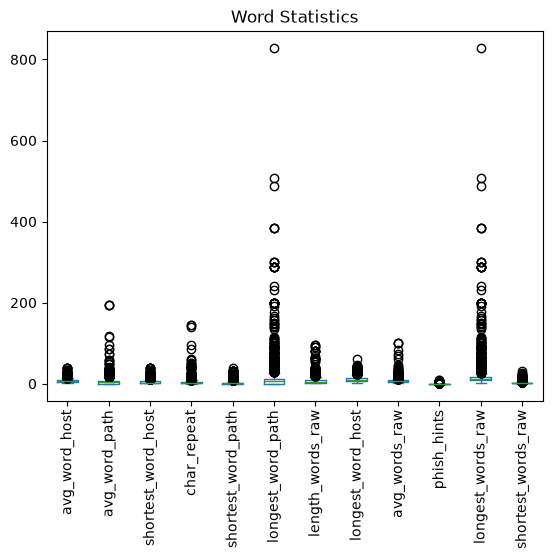

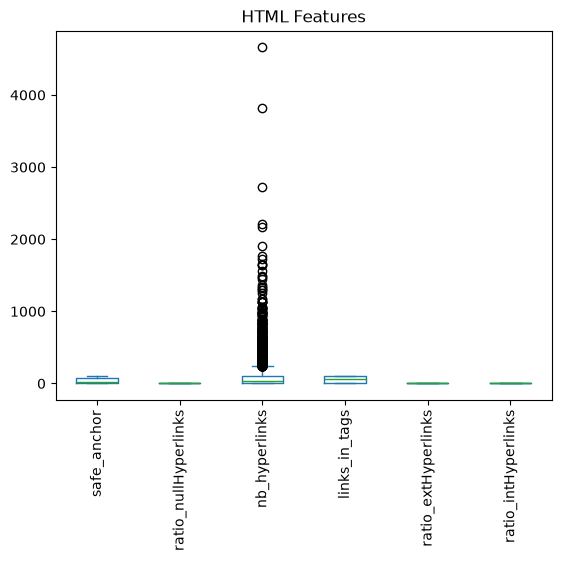

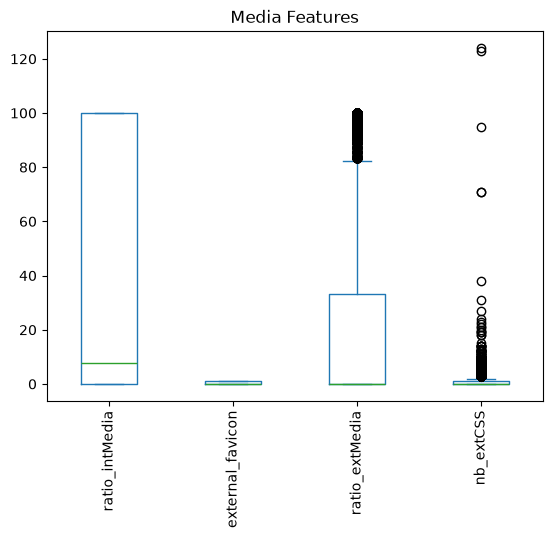

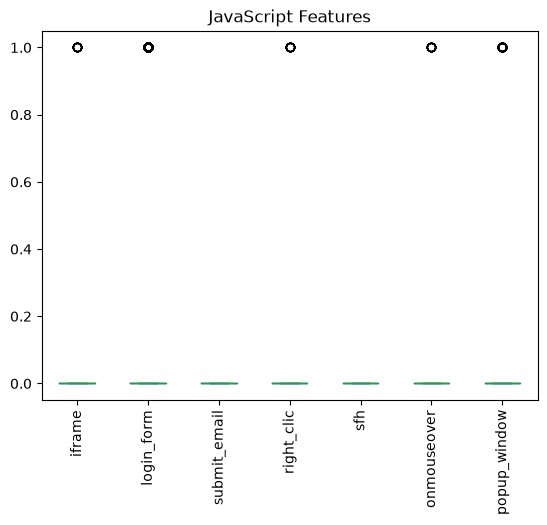

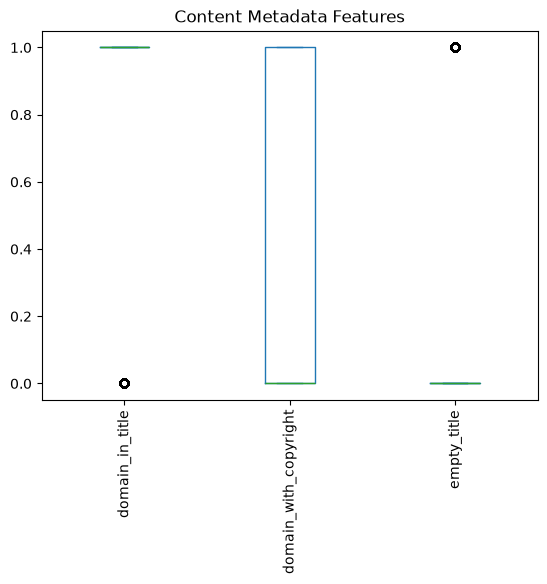

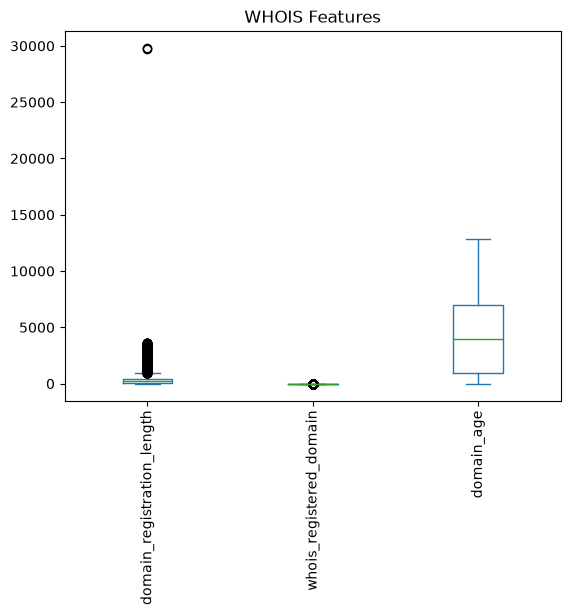

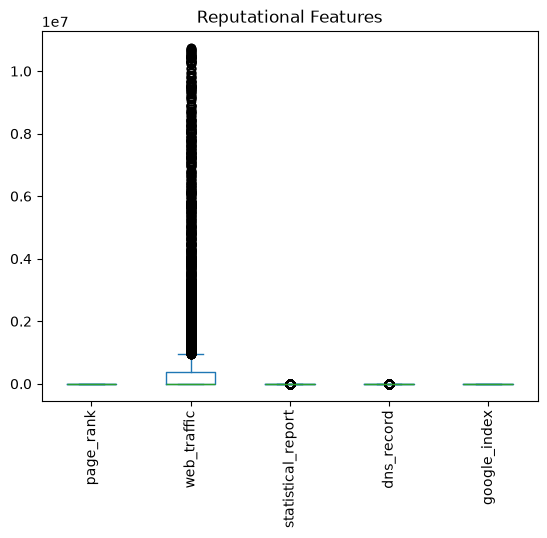

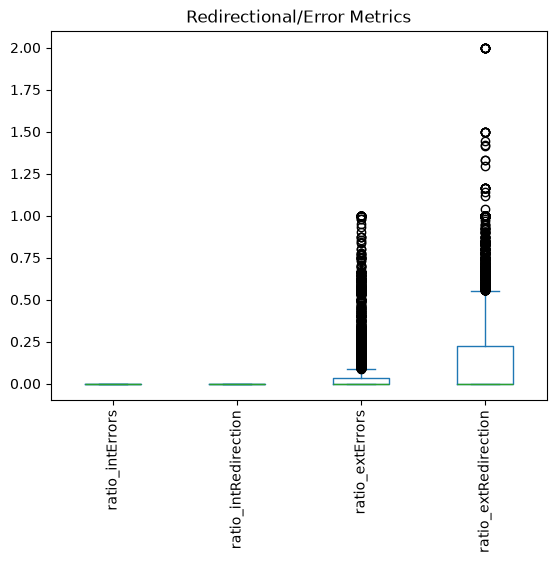

In [4]:
for title, columns in FEATURE_CATEGORIES.items():
    data_frame = generate_sub_data_frame(columns, add_status=False)
    frame_box_plot(
        data_frame, title
    )

### Boolean Attributes
These are attributes that indicate whether a specific feature is present or not present.

In [5]:
BOOLEAN_ATTRIBUTES = set(
    full_data_frame.loc[:, (full_data_frame.nunique() == 2)]. columns
)

len(BOOLEAN_ATTRIBUTES)

32

### Non-Boolean Attributes
These attributes are much more diverse and complex in comparison to boolean attributes. This includes numerical values asides from 0 and 1 and URLs themselves.

In [6]:
NON_BOOL_ATTRIBUTES = set(
    full_data_frame.loc[:, (full_data_frame.nunique() > 2)].columns
)

len(NON_BOOL_ATTRIBUTES)

51

## Removing Redundant Attributes

### Constant Features
These are features whose values are all the same across every URL and thereby serve no purpose in distinguishing between a phishing link and a legitimate link.

In [7]:
REDUNDANT_FEATURES = set(
    full_data_frame.loc[:, (full_data_frame.nunique() == 1)].columns
)

save_redundant_features(REDUNDANT_FEATURES)

REDUNDANT_FEATURES

{'nb_or',
 'ratio_intErrors',
 'ratio_intRedirection',
 'ratio_nullHyperlinks',
 'sfh',
 'submit_email'}

Below we remove these features to address the curse of dimensionality.

In [8]:
RELEVANT_FEATURES = get_relevant_features(full_data_frame)

### Highly Correlated Features
These features can be identified visually via a correlation matrix.

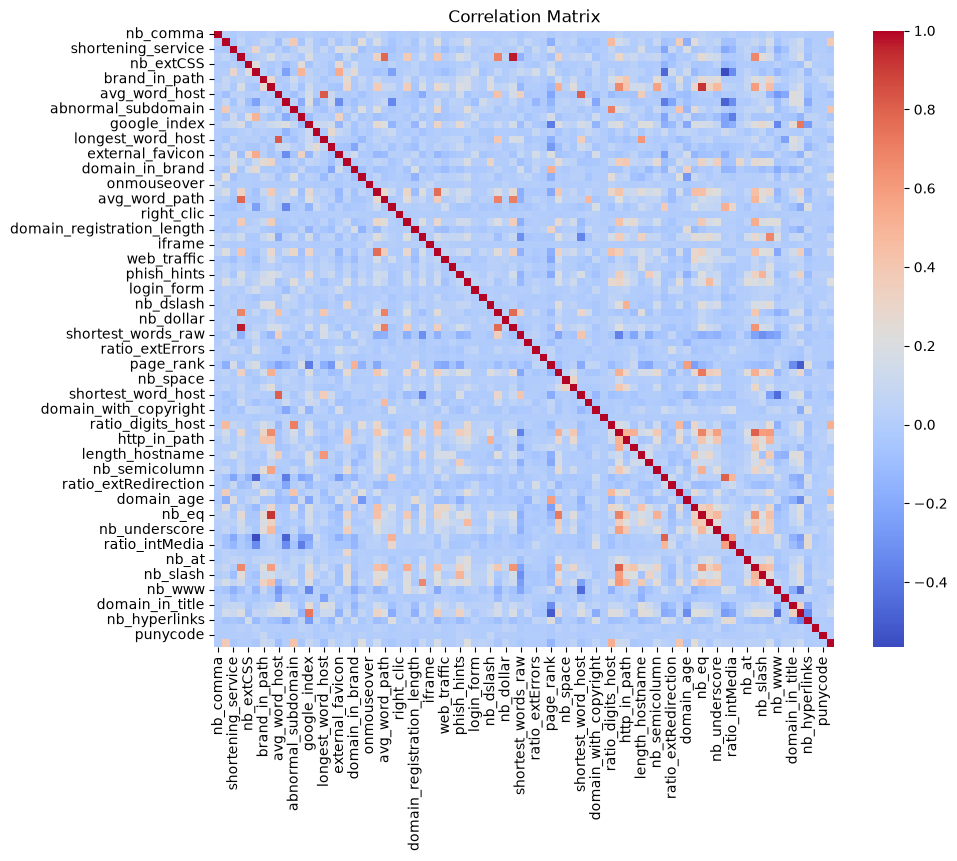

In [9]:
cleaned_data_frame_1 = generate_sub_data_frame(
    RELEVANT_FEATURES
)

frame_correlation_matrix(cleaned_data_frame_1, annotate=False)

#### Top 10 Highest Correlation Pairings

In [10]:
get_top_correlation_pairs(cleaned_data_frame_1, 10)

longest_word_path    longest_words_raw    0.969159
nb_eq                nb_and               0.920944
avg_word_host        longest_word_host    0.820717
shortest_word_host   avg_word_host        0.809354
ratio_intHyperlinks  links_in_tags        0.800605
length_words_raw     length_url           0.799836
avg_word_path        longest_word_path    0.783384
avg_words_raw        longest_words_raw    0.775309
ip                   ratio_digits_url     0.764657
status               google_index         0.734620
dtype: float64

#### Highly Correlated Pairs
Each pair represents a highly-correlated intersecting point in the correlation matrix.

In [11]:
get_highly_correlated_pairs(cleaned_data_frame_1)

{('avg_word_host', 'longest_word_host'),
 ('length_words_raw', 'length_url'),
 ('longest_word_path', 'longest_words_raw'),
 ('nb_eq', 'nb_and'),
 ('ratio_intHyperlinks', 'links_in_tags'),
 ('shortest_word_host', 'avg_word_host')}

#### Redundant Feature Inference from Correlation
From each of the highly-correlated pairing of features shown above, we can infer the feature that is most redundant based on each feature's correlation value to determining the *status* of a URL.

In [12]:
REDUNDANT_FEATURES.update(
    get_redundant_correlated_features(cleaned_data_frame_1)
)

save_redundant_features(REDUNDANT_FEATURES)

get_redundant_correlated_features(cleaned_data_frame_1)

{'avg_word_host',
 'length_words_raw',
 'links_in_tags',
 'longest_word_host',
 'longest_words_raw',
 'nb_and'}

In [13]:
REDUNDANT_FEATURES.update(
    get_low_target_correlation_features(cleaned_data_frame_1)
)

save_redundant_features(REDUNDANT_FEATURES)

get_low_target_correlation_features(cleaned_data_frame_1)

{'iframe', 'nb_space', 'onmouseover', 'path_extension', 'right_clic'}

In [14]:
REDUNDANT_FEATURES.update(
    get_redundant_correlated_features(cleaned_data_frame_1)
)

save_redundant_features(REDUNDANT_FEATURES)

REDUNDANT_FEATURES

{'avg_word_host',
 'iframe',
 'length_words_raw',
 'links_in_tags',
 'longest_word_host',
 'longest_words_raw',
 'nb_and',
 'nb_or',
 'nb_space',
 'onmouseover',
 'path_extension',
 'ratio_intErrors',
 'ratio_intRedirection',
 'ratio_nullHyperlinks',
 'right_clic',
 'sfh',
 'submit_email'}

In [15]:
RELEVANT_FEATURES = get_relevant_features(cleaned_data_frame_1)

len(RELEVANT_FEATURES)

71

## Clean Dataset Context

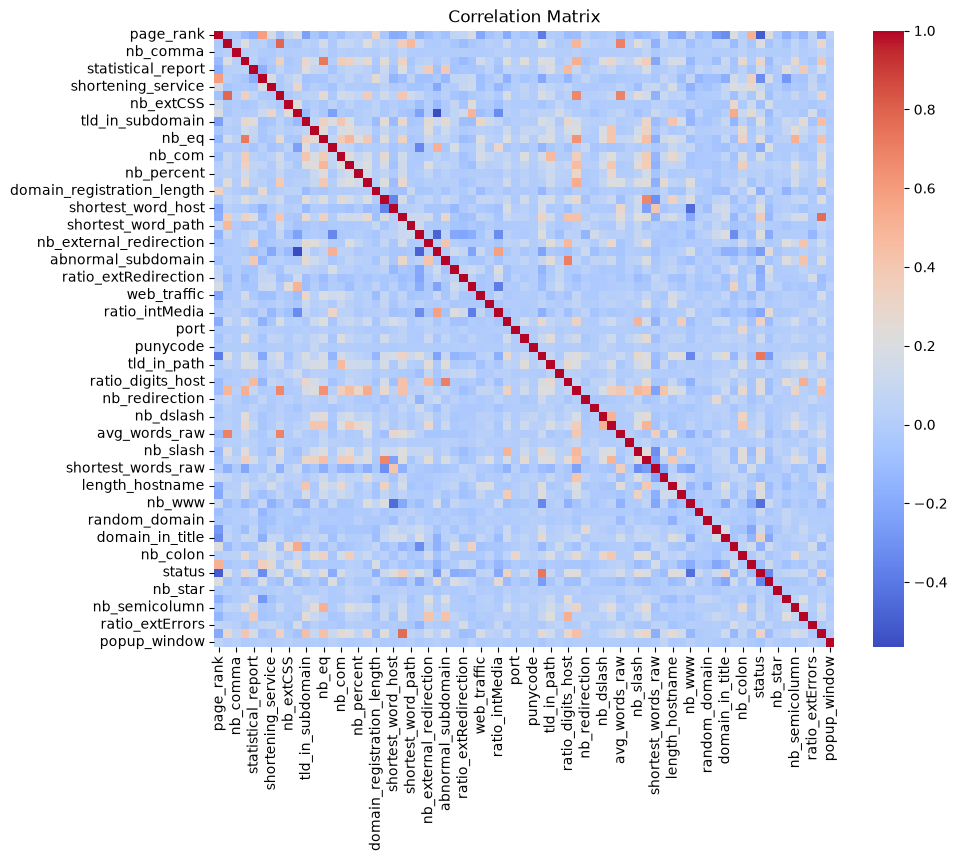

In [16]:
cleaned_data_frame_2 = generate_sub_data_frame(
    RELEVANT_FEATURES
)

frame_correlation_matrix(cleaned_data_frame_2, annotate=False)

In [17]:
get_top_correlation_pairs(cleaned_data_frame_2, 10)

longest_word_path  avg_word_path         0.783384
ip                 ratio_digits_url      0.764657
google_index       status                0.734620
nb_qm              nb_eq                 0.725301
ratio_digits_host  abnormal_subdomain    0.704427
avg_words_raw      avg_word_path         0.699656
                   longest_word_path     0.689232
nb_subdomains      nb_dots               0.678439
longest_word_path  length_url            0.675539
nb_eq              length_url            0.637347
dtype: float64

In [18]:
get_correlation_to_target(
    set(cleaned_data_frame_2.columns)
)

status                 1.000000
google_index           0.734620
ratio_digits_url       0.354270
domain_in_title        0.335234
phish_hints            0.331244
                         ...   
ratio_intHyperlinks   -0.256211
domain_age            -0.323937
nb_hyperlinks         -0.342196
nb_www                -0.440457
page_rank             -0.503594
Name: status, Length: 71, dtype: float64